In [1]:
import cv2
import torch
import torchvision
from torchvision import transforms  # Load a pre-trained object detection model
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
import urllib.request
import datetime
import time

for x in range(0,8):
    print(x)

    image_name = "./images/grca_webcam " + str(datetime.datetime.now())[:13] + ".jpg"
    urllib.request.urlretrieve("https://www.nps.gov/webcams-grca/camera.jpg?1681152006251", image_name)
    time.sleep(60*60)


0
1
2
3


In [2]:
col_frames = os.listdir('./images/')
analysis_img  = cv2.imread('./images/'+col_frames[2])


In [3]:
col_frames

['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'GRCA webcam no vehicles 11282022.jpg',
 'grca_webcam 2023-01-24 18.jpg',
 'grca_webcam 2023-02-02 18.jpg',
 'grca_webcam no vehicles snow 2023-01-24 17.jpg',
 'grca_webcam.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg']

In [4]:
analysis_img.shape

(960, 1296, 3)

In [5]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval() # Define the transformation to be applied on the image
transform = transforms.Compose([transforms.ToTensor()]) # Open a video stream


C:\Users\Eric.Englin\Anaconda3\envs\geo_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Eric.Englin\Anaconda3\envs\geo_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]


In [7]:
COCO_INSTANCE_CATEGORY_NAMES[3], COCO_INSTANCE_CATEGORY_NAMES[62]

('car', 'chair')

In [8]:
count = 0
image = cv2.imread('./images/'+col_frames[2])
image = transform(image).unsqueeze(0) # Pass the image through the model to get the predictions    
with torch.no_grad():
    outputs = model(image) # Extract the bounding boxes and labels from the outputs    
    boxes = outputs[0]['boxes'].data.numpy()
    labels = outputs[0]['labels'].data.numpy() # Filter the predictions to keep only the vehicle instances    
    vehicle_boxes = boxes[(labels==6)|(labels==8)|(labels==3)] # 7 is the class index for vehicles in COCO dataset    
                                        # https://haochen23.github.io/2020/04/object-detection-faster-rcnn.html#.Y9vwMXbMKUk
    # Increment the count by the number of vehicle instances in the frame    
    count += len(vehicle_boxes) # Display the frame with the bounding boxes and the count   
    non_vehicle_boxes = boxes[(labels!=6)|(labels!=8)|(labels!=3)] # 7 is the class index for vehicles in COCO dataset    


print(count)

74


In [9]:
def vehicle_classifier(x, rectthreshold, eps):

    image = cv2.imread('./images/'+col_frames[x])
    image[600 : 960, 0 : 1296] = (0, 0, 0)
    image = transform(image).unsqueeze(0) # Pass the image through the model to get the predictions    
    with torch.no_grad():
        outputs = model(image) # Extract the bounding boxes and labels from the outputs    
        boxes = outputs[0]['boxes'].data.numpy()
        labels = outputs[0]['labels'].data.numpy() # Filter the predictions to keep only the vehicle instances    
        scores = outputs[0]['scores'].data.numpy() # Filter the predictions to keep only the vehicle instances    
        vehicle_boxes = boxes[(labels==6)|(labels==8)|(labels==3)] # 7 is the class index for vehicles in COCO dataset    
                                            # https://haochen23.github.io/2020/04/object-detection-faster-rcnn.html#.Y9vwMXbMKUk
        # Increment the count by the number of vehicle instances in the frame    
    image = cv2.imread('./images/'+col_frames[x])

    for box in vehicle_boxes:
        x1, y1, x2, y2 = box
        x_val = abs(x2-x1)
        y_val = abs(y2-y1)
        area = x_val*y_val
        if area < 960*1250/6:
            cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
            cv2.putText(image, "Vehicle Count: {}".format(count), (10, 850), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

   # plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  #  plt.show()
    
    other_vehicle_boxes = groupRect(vehicle_boxes.astype(int), rectthreshold=rectthreshold, eps=eps)

    total_area = 0
    original_image = cv2.imread('./images/'+col_frames[x])
    for box in other_vehicle_boxes:
        for little_box in box:
            x1, y1, x2, y2 = little_box
            x = abs(x2-x1)
            y = abs(y2-y1)
            area = x*y
            if area < 960*1250/6:
                total_area += area
                cv2.rectangle(original_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)

    print(round(total_area/(960*1296)*100, 2), "% area coverage")
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.show()


In [10]:
def groupRect(rectarray, rectthreshold=1, eps=0.1):
    """
    Groups similar rectangles together in rectangle array \n
    Input : Rectangle Array \n
    Output : Rectangle Array without split parts
    """
    results = cv2.groupRectangles(np.concatenate((rectarray, rectarray)),rectthreshold,eps=eps)[0]
    results = [[group] for group in results]
    return np.array(results)


1 ,  0.01
18.48 % area coverage


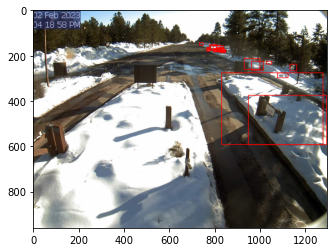

23.97 % area coverage


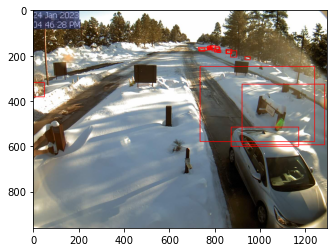

1 ,  0.025
18.17 % area coverage


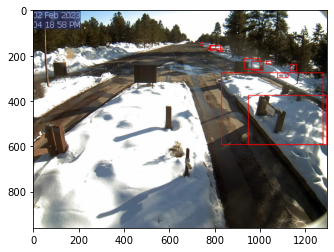

23.79 % area coverage


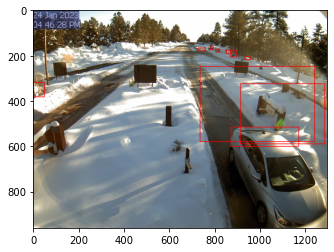

1 ,  0.05
17.79 % area coverage


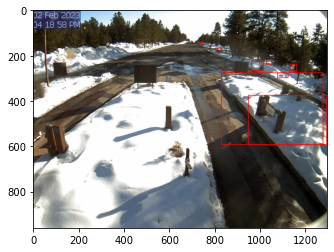

23.51 % area coverage


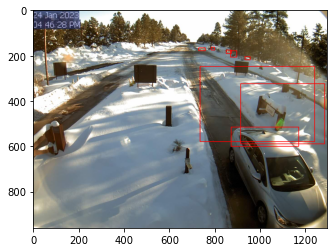

1 ,  0.1
17.72 % area coverage


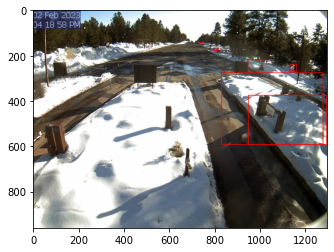

23.4 % area coverage


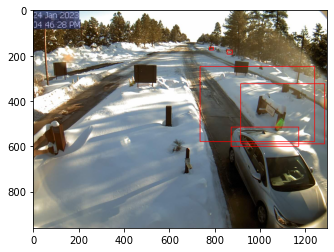

1 ,  0.15
8.78 % area coverage


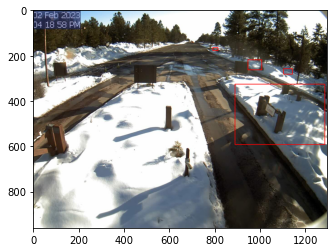

9.94 % area coverage


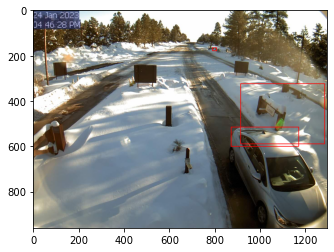

In [11]:
for rectthreshold in [1]:
    for eps in [0.01, 0.025, .05, .1, .15]:
        print(rectthreshold, ", ", eps)
        vehicle_classifier(5, rectthreshold, eps)
        vehicle_classifier(4, rectthreshold, eps)

15.88 % area coverage


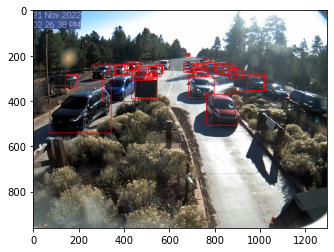

19.86 % area coverage


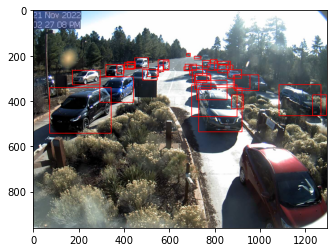

38.88 % area coverage


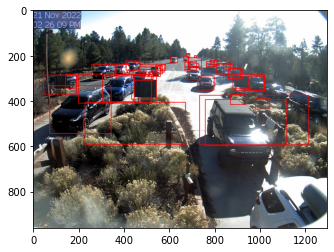

0.39 % area coverage


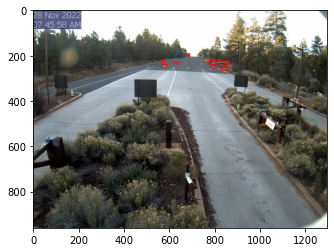

23.79 % area coverage


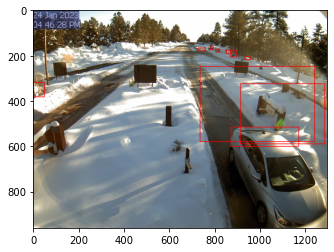

18.17 % area coverage


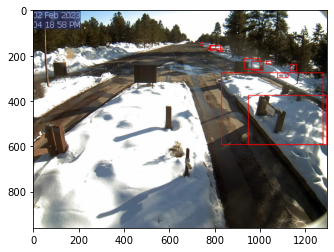

11.27 % area coverage


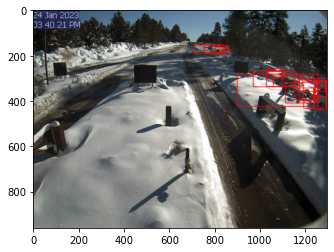

1.05 % area coverage


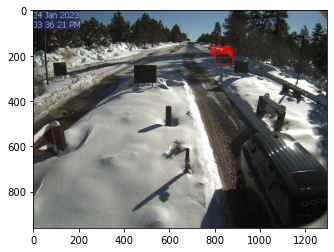

37.81 % area coverage


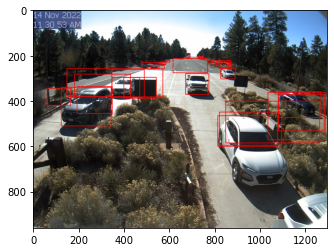

23.35 % area coverage


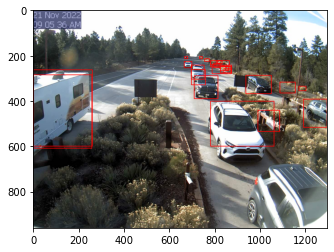

12.61 % area coverage


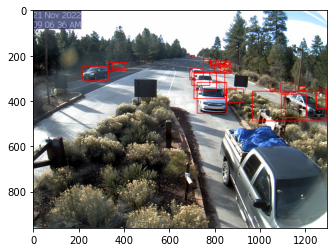

In [12]:
col_frames = os.listdir('./images/')
len(col_frames)
for x in range(0, len(col_frames)):
    vehicle_classifier(x, 1, 0.025)

In [14]:
vehicle_boxes.shape, non_vehicle_boxes.shape

((74, 4), (100, 4))

In [15]:
label_list = []
for x in labels:
    if x not in label_list:        
        label_list.append(x)
        print(COCO_INSTANCE_CATEGORY_NAMES[x], ": ", x)

car :  3
chair :  62
truck :  8
person :  1
motorcycle :  4
broccoli :  56
potted plant :  64
elephant :  22
parking meter :  14
traffic light :  10
cow :  21
bus :  6
kite :  38
backpack :  27
bear :  23


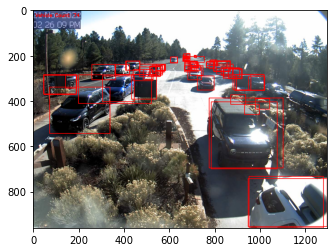

In [16]:
analysis_img = cv2.imread('./images/'+col_frames[2])

for box in vehicle_boxes:
    x1, y1, x2, y2 = box
    cv2.rectangle(analysis_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(analysis_img, "Vehicle Count: {}".format(count), (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
plt.imshow(cv2.cvtColor(analysis_img, cv2.COLOR_BGR2RGB))
plt.show()

In [17]:
other_vehicle_boxes = groupRect(vehicle_boxes.astype(int), rectthreshold=1, eps=0.1)

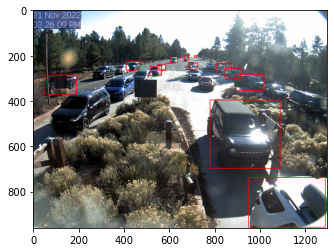

In [18]:
analysis_img = cv2.imread('./images/'+col_frames[2])
other_vehicle_boxes = groupRect(vehicle_boxes.astype(int), rectthreshold=2, eps=0.05)

for box in other_vehicle_boxes:
    for little_box in box:
        x1, y1, x2, y2 = little_box

        cv2.rectangle(analysis_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(analysis_img, cv2.COLOR_BGR2RGB))
plt.show()

In [19]:
140*113/(960*1250)

0.013183333333333333

In [20]:
total_area = 0
for box in other_vehicle_boxes:
    for little_box in box:
        x1, y1, x2, y2 = little_box
        x = abs(x2-x1)
        y = abs(y2-y1)
        area = x*y
        total_area += area

print(round(total_area/(960*1250)*100, 2), "% area coverage")

16.75 % area coverage


('./images/grca_webcam 2023-04-10 14.jpg',
 <http.client.HTTPMessage at 0x232085b67a0>)